<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/16_custom_lr_scheduler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 16 — Custom Learning Rate Schedulers

## What This Notebook Covers
The learning rate is the single most important hyperparameter in deep learning.
A fixed learning rate is almost never optimal:
- Too high early on: unstable training, divergence
- Too high late on: oscillates around minima, never converges
- Too low throughout: painfully slow convergence

Learning rate **scheduling** varies the LR over time. This notebook
builds every scheduler from scratch to show exactly what each one does.

**Schedulers covered:**
- Step decay
- Exponential decay
- Cosine annealing
- Warmup + cosine (WarmupCosineDecay)
- OneCycleLR (fastai / super-convergence)
- Custom Keras callback scheduler
- Custom PyTorch scheduler
- A/B test: fixed LR vs best schedule

**Both TensorFlow/Keras and PyTorch implementations shown.**

**Dataset:** Fashion-MNIST


In [ ]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import math

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data


In [ ]:
# TensorFlow
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]
print('TF data ready.')

# PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full_pt = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set_pt   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_set_pt, valid_set_pt = torch.utils.data.random_split(
    train_full_pt, [55000, 5000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set_pt, batch_size=64, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_set_pt, batch_size=64, shuffle=False, pin_memory=True)
print('PyTorch data ready.')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
TF data ready.


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.8MB/s]

PyTorch data ready.


## 2. Visualise All Schedules Before Training

Always plot your learning rate schedule before training.
This lets you verify the shape is what you intended and
catch bugs in your schedule function early.


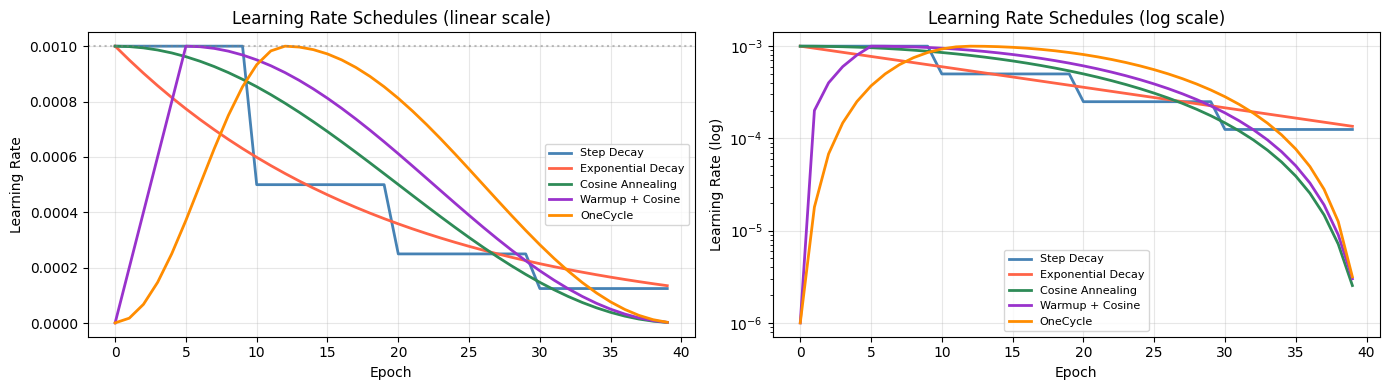

Always plot your schedule before training to verify its shape.


In [ ]:
EPOCHS      = 40
INITIAL_LR  = 1e-3
MIN_LR      = 1e-6

def step_decay_schedule(epoch, initial_lr=INITIAL_LR, drop=0.5, epochs_drop=10):
    """
    Halve LR every epochs_drop epochs.
    LR = initial_lr * drop ^ floor(epoch / epochs_drop)
    Creates a staircase pattern.
    """
    return initial_lr * (drop ** (epoch // epochs_drop))


def exponential_decay_schedule(epoch, initial_lr=INITIAL_LR, decay_rate=0.95):
    """
    Multiply LR by decay_rate every epoch.
    LR = initial_lr * decay_rate ^ epoch
    Smooth exponential decrease.
    """
    return initial_lr * (decay_rate ** epoch)


def cosine_annealing_schedule(epoch, initial_lr=INITIAL_LR,
                               min_lr=MIN_LR, total_epochs=EPOCHS):
    """
    Cosine annealing: LR follows the cosine curve from initial_lr to min_lr.
    LR = min_lr + 0.5 * (initial_lr - min_lr) * (1 + cos(pi * epoch / total))
    Smooth decrease that slows near the end.
    """
    cosine_decay = 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))
    return min_lr + (initial_lr - min_lr) * cosine_decay


def warmup_cosine_schedule(epoch, initial_lr=INITIAL_LR,
                            min_lr=MIN_LR, total_epochs=EPOCHS,
                            warmup_epochs=5):
    """
    Linear warmup for warmup_epochs, then cosine decay.
    Warmup prevents instability when weights are random at start.

    epoch 0..warmup_epochs: LR ramps from min_lr to initial_lr
    epoch warmup_epochs..total: cosine decay from initial_lr to min_lr
    """
    if epoch < warmup_epochs:
        # Linear warmup
        return min_lr + (initial_lr - min_lr) * (epoch / warmup_epochs)
    else:
        # Cosine decay after warmup
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        cosine   = 0.5 * (1 + math.cos(math.pi * progress))
        return min_lr + (initial_lr - min_lr) * cosine


def one_cycle_schedule(epoch, total_epochs=EPOCHS,
                        max_lr=INITIAL_LR, min_lr=MIN_LR,
                        pct_start=0.3):
    """
    OneCycleLR (fastai / super-convergence paper):
    - Phase 1 (pct_start * total): ramp LR from min_lr to max_lr
    - Phase 2 (rest): decay LR from max_lr back down past min_lr

    The key insight: a single large LR spike followed by decay
    allows very fast convergence (super-convergence).
    """
    up_epochs   = int(total_epochs * pct_start)
    down_epochs = total_epochs - up_epochs

    if epoch < up_epochs:
        # Cosine ramp UP
        progress = epoch / up_epochs
        cosine   = 0.5 * (1 - math.cos(math.pi * progress))
        return min_lr + (max_lr - min_lr) * cosine
    else:
        # Cosine ramp DOWN (to even lower than min_lr)
        progress = (epoch - up_epochs) / down_epochs
        cosine   = 0.5 * (1 + math.cos(math.pi * progress))
        return min_lr * 0.01 + (max_lr - min_lr * 0.01) * cosine


# Plot all schedules together
epochs_range = np.arange(EPOCHS)
schedules = {
    'Step Decay':          [step_decay_schedule(e)        for e in epochs_range],
    'Exponential Decay':   [exponential_decay_schedule(e) for e in epochs_range],
    'Cosine Annealing':    [cosine_annealing_schedule(e)  for e in epochs_range],
    'Warmup + Cosine':     [warmup_cosine_schedule(e)     for e in epochs_range],
    'OneCycle':            [one_cycle_schedule(e)         for e in epochs_range],
}

colors = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'darkorange']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Linear scale
for (name, lrs), color in zip(schedules.items(), colors):
    axes[0].plot(epochs_range, lrs, label=name, color=color, linewidth=2)
axes[0].set_title('Learning Rate Schedules (linear scale)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning Rate')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(INITIAL_LR, color='grey', linestyle=':', alpha=0.5, label='Initial LR')

# Log scale (easier to compare schedules with very different magnitudes)
for (name, lrs), color in zip(schedules.items(), colors):
    axes[1].semilogy(epochs_range, lrs, label=name, color=color, linewidth=2)
axes[1].set_title('Learning Rate Schedules (log scale)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate (log)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Always plot your schedule before training to verify its shape.')

---
## Part A — TensorFlow / Keras

### 3. Using LearningRateScheduler Callback

Pass a Python function to `LearningRateScheduler`. It receives
`(epoch, current_lr)` and returns the new LR.


In [ ]:
def make_model_tf():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(256, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])
    return model


def train_tf(schedule_fn, label='', epochs=EPOCHS):
    """Train a TF model with a given LR schedule function."""
    tf.random.set_seed(42)
    model = make_model_tf()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    lr_callback = tf.keras.callbacks.LearningRateScheduler(
        lambda epoch, lr: schedule_fn(epoch),
        verbose=0
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=64,
        callbacks=[lr_callback],
        verbose=0
    )
    best_val = max(history.history['val_accuracy'])
    print(f'{label:30s} -> best val accuracy: {best_val:.4f}')
    return history


# Fixed LR baseline
def fixed_lr_schedule(epoch): return INITIAL_LR

print('Training with each schedule...')
histories_tf = {
    'Fixed LR':          train_tf(fixed_lr_schedule,           'Fixed LR (1e-3)'),
    'Step Decay':        train_tf(step_decay_schedule,         'Step Decay'),
    'Exponential Decay': train_tf(exponential_decay_schedule,  'Exponential Decay'),
    'Cosine Annealing':  train_tf(cosine_annealing_schedule,   'Cosine Annealing'),
    'Warmup + Cosine':   train_tf(warmup_cosine_schedule,      'Warmup + Cosine'),
    'OneCycle':          train_tf(one_cycle_schedule,          'OneCycle'),
}

Training with each schedule...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fixed LR (1e-3)                -> best val accuracy: 0.8974
Step Decay                     -> best val accuracy: 0.8996
Exponential Decay              -> best val accuracy: 0.9020
Cosine Annealing               -> best val accuracy: 0.8998
Warmup + Cosine                -> best val accuracy: 0.9038
OneCycle                       -> best val accuracy: 0.8978


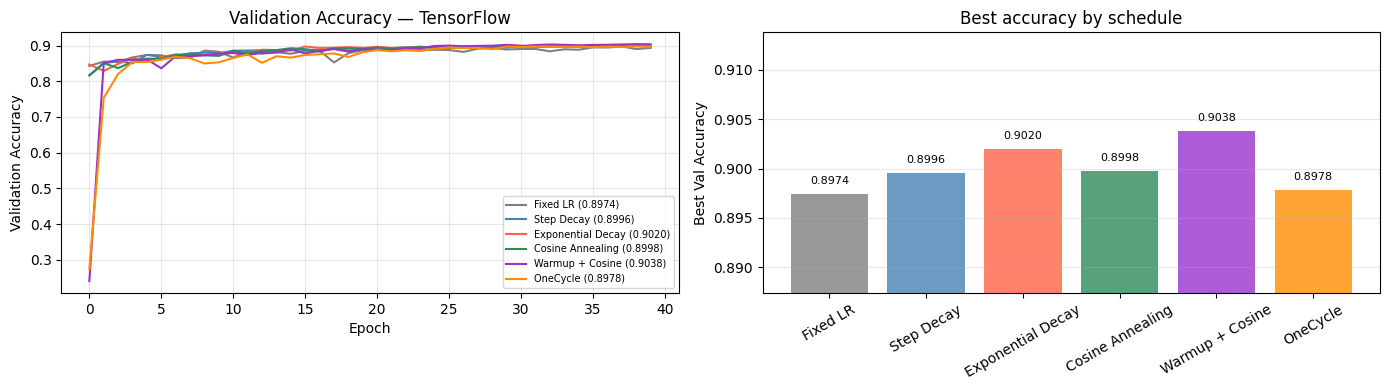

In [ ]:
# Plot validation accuracy for all schedules
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

schedule_colors = {
    'Fixed LR':          'grey',
    'Step Decay':        'steelblue',
    'Exponential Decay': 'tomato',
    'Cosine Annealing':  'seagreen',
    'Warmup + Cosine':   'darkorchid',
    'OneCycle':          'darkorange',
}

for name, hist in histories_tf.items():
    axes[0].plot(hist.history['val_accuracy'],
                 label=f'{name} ({max(hist.history["val_accuracy"]):.4f})',
                 color=schedule_colors[name], linewidth=1.5)

axes[0].set_title('Validation Accuracy — TensorFlow')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# Best val accuracy bar chart
names = list(histories_tf.keys())
bests = [max(h.history['val_accuracy']) for h in histories_tf.values()]
bars  = axes[1].bar(names, bests,
                     color=[schedule_colors[n] for n in names],
                     alpha=0.8)
for bar, acc in zip(bars, bests):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{acc:.4f}', ha='center', fontsize=8)
axes[1].set_ylabel('Best Val Accuracy')
axes[1].set_title('Best accuracy by schedule')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(min(bests) - 0.01, max(bests) + 0.01)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 4. Custom Keras Callback Scheduler

For more control, subclass `tf.keras.callbacks.Callback`.
This lets you track LR history, add logging, or implement
logic that depends on training state.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Per-step OneCycle best val accuracy: 0.9016


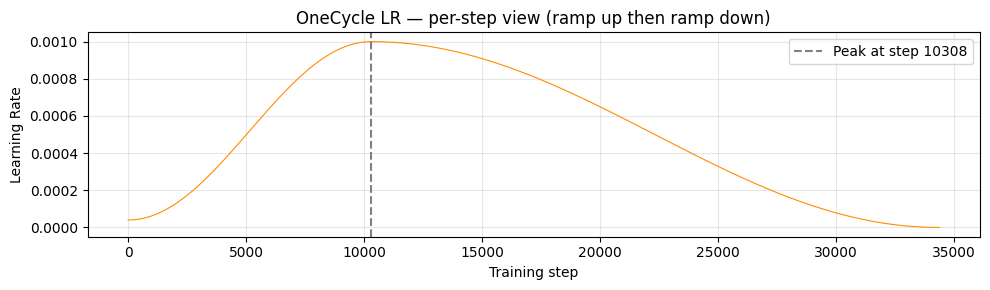

In [ ]:
class OneCycleScheduler(tf.keras.callbacks.Callback):
    """
    Custom Keras callback implementing the OneCycle LR policy.

    Based on the paper 'Super-Convergence' (Smith & Topin, 2018).
    The LR is annealed using cosine functions:
    - Phase 1: min_lr -> max_lr over pct_start * total_steps
    - Phase 2: max_lr -> min_lr * final_div_factor over remaining steps

    Note: this operates per STEP (not per epoch) for finer control.
    """
    def __init__(self, max_lr, steps_per_epoch, epochs,
                 pct_start=0.3, div_factor=25.0, final_div=1e4):
        super().__init__()
        self.max_lr          = max_lr
        self.min_lr          = max_lr / div_factor
        self.final_lr        = max_lr / final_div
        self.total_steps     = steps_per_epoch * epochs
        self.up_steps        = int(self.total_steps * pct_start)
        self.down_steps      = self.total_steps - self.up_steps
        self.current_step    = 0
        self.lr_history      = []

    def _get_lr(self):
        if self.current_step < self.up_steps:
            # Cosine ramp up
            pct  = self.current_step / self.up_steps
            cos  = 0.5 * (1 - math.cos(math.pi * pct))
            return self.min_lr + (self.max_lr - self.min_lr) * cos
        else:
            # Cosine ramp down
            pct  = (self.current_step - self.up_steps) / self.down_steps
            cos  = 0.5 * (1 + math.cos(math.pi * pct))
            return self.final_lr + (self.max_lr - self.final_lr) * cos

    def on_train_batch_begin(self, batch, logs=None):
        lr = self._get_lr()
        # tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
        self.model.optimizer.learning_rate.assign(lr)
        self.lr_history.append(lr)

    def on_train_batch_end(self, batch, logs=None):
        self.current_step += 1


# Train with the custom per-step OneCycle scheduler
STEPS_PER_EPOCH = len(X_train) // 64
TRAIN_EPOCHS    = EPOCHS

tf.random.set_seed(42)
model_onecycle = make_model_tf()
model_onecycle.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

onecycle_cb = OneCycleScheduler(
    max_lr=INITIAL_LR,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=TRAIN_EPOCHS,
    pct_start=0.3,
    div_factor=25.0,
    final_div=1e4
)

history_onecycle = model_onecycle.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=TRAIN_EPOCHS,
    batch_size=64,
    callbacks=[onecycle_cb],
    verbose=0
)

print(f'Per-step OneCycle best val accuracy: '
      f'{max(history_onecycle.history["val_accuracy"]):.4f}')

# Plot the per-step LR curve
plt.figure(figsize=(10, 3))
plt.plot(onecycle_cb.lr_history, color='darkorange', linewidth=0.8)
plt.axvline(onecycle_cb.up_steps, color='grey', linestyle='--',
             label=f'Peak at step {onecycle_cb.up_steps}')
plt.xlabel('Training step')
plt.ylabel('Learning Rate')
plt.title('OneCycle LR — per-step view (ramp up then ramp down)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. tf.keras.optimizers.schedules — Built-in Schedules

Keras also has built-in schedule objects you can pass directly
to an optimizer instead of using a callback.
These are more efficient because they run inside the TF graph.


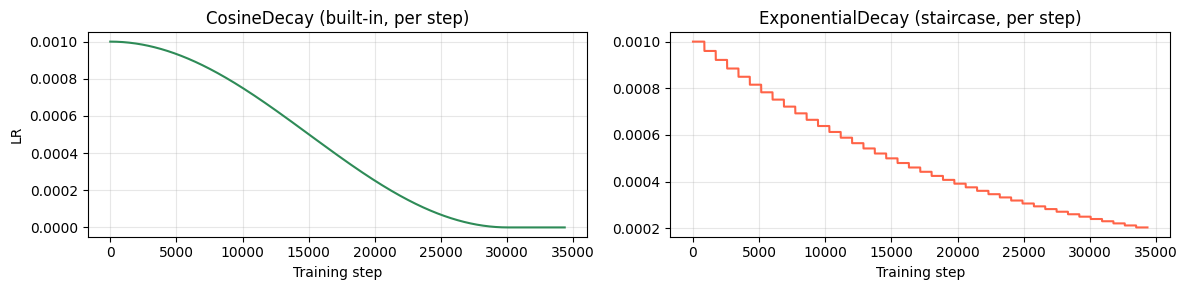

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


CosineDecay (built-in) best val accuracy: 0.9034


In [ ]:
# CosineDecay with warmup (built-in in TF2.x)
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS = STEPS_PER_EPOCH * 5   # 5 warmup epochs

cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=TOTAL_STEPS - WARMUP_STEPS,
    alpha=1e-6   # min LR
)

# ExponentialDecay: built-in per-step exponential LR
exp_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=STEPS_PER_EPOCH,   # decay every epoch
    decay_rate=0.96,
    staircase=True                 # step-wise instead of continuous
)

# Visualise built-in schedules
steps = np.arange(TOTAL_STEPS)
cosine_lrs = [float(cosine_schedule(s)) for s in steps]
exp_lrs    = [float(exp_schedule(s))    for s in steps]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(steps, cosine_lrs, color='seagreen')
axes[0].set_title('CosineDecay (built-in, per step)')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('LR')
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, exp_lrs, color='tomato')
axes[1].set_title('ExponentialDecay (staircase, per step)')
axes[1].set_xlabel('Training step')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Train using built-in cosine schedule
tf.random.set_seed(42)
model_builtin = make_model_tf()
model_builtin.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
hist_builtin = model_builtin.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS, batch_size=64, verbose=0
)
print(f'CosineDecay (built-in) best val accuracy: '
      f'{max(hist_builtin.history["val_accuracy"]):.4f}')

---
## Part B — PyTorch Custom Scheduler

### 6. Custom PyTorch LR Scheduler

PyTorch schedulers subclass `torch.optim.lr_scheduler.LRScheduler`
(or `_LRScheduler` in older versions) and implement `get_lr()`.


/tmp/ipykernel_5278/948669288.py:63: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  dummy_scheduler.step()


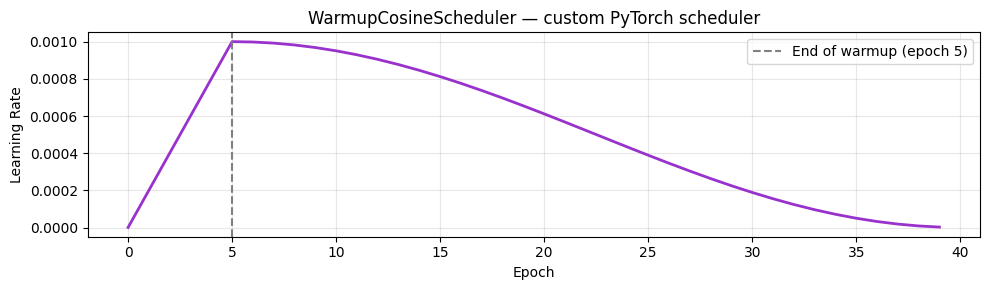

LR at epoch 0 (start of warmup): 1.00e-06
LR at epoch 5 (peak):             1.00e-03
LR at epoch 39 (end):             3.01e-06


In [ ]:
from torch.optim.lr_scheduler import _LRScheduler

class WarmupCosineScheduler(_LRScheduler):
    """
    Custom PyTorch scheduler: linear warmup then cosine annealing.

    Subclasses _LRScheduler and implements get_lr().
    get_lr() is called each time scheduler.step() is invoked.
    It returns a list of LRs (one per param group).

    Usage:
        optimizer = Adam(...)
        scheduler = WarmupCosineScheduler(optimizer, warmup_epochs=5,
                                           total_epochs=40, min_lr=1e-6)
        for epoch in range(40):
            train(...)
            scheduler.step()   # call once per epoch
    """
    def __init__(self, optimizer, warmup_epochs, total_epochs,
                 min_lr=1e-6, last_epoch=-1):
        self.warmup_epochs  = warmup_epochs
        self.total_epochs   = total_epochs
        self.min_lr         = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        """
        Returns list of LRs for each param group.
        self.last_epoch is the current epoch (starts at 0).
        self.base_lrs are the initial LRs from the optimizer.
        """
        epoch = self.last_epoch

        if epoch < self.warmup_epochs:
            # Linear warmup: ramp from min_lr to base_lr
            scale = epoch / max(self.warmup_epochs, 1)
            return [
                self.min_lr + (base_lr - self.min_lr) * scale
                for base_lr in self.base_lrs
            ]
        else:
            # Cosine annealing after warmup
            progress = ((epoch - self.warmup_epochs) /
                         max(self.total_epochs - self.warmup_epochs, 1))
            cosine   = 0.5 * (1 + math.cos(math.pi * progress))
            return [
                self.min_lr + (base_lr - self.min_lr) * cosine
                for base_lr in self.base_lrs
            ]


# Test: verify LR values
dummy_optimizer = torch.optim.Adam(
    [torch.nn.Parameter(torch.zeros(1))], lr=INITIAL_LR
)
dummy_scheduler = WarmupCosineScheduler(
    dummy_optimizer, warmup_epochs=5, total_epochs=EPOCHS
)

lr_trace = []
for e in range(EPOCHS):
    lr_trace.append(dummy_optimizer.param_groups[0]['lr'])
    dummy_scheduler.step()

plt.figure(figsize=(10, 3))
plt.plot(lr_trace, color='darkorchid', linewidth=2)
plt.axvline(5, color='grey', linestyle='--', label='End of warmup (epoch 5)')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('WarmupCosineScheduler — custom PyTorch scheduler')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('LR at epoch 0 (start of warmup):', f'{lr_trace[0]:.2e}')
print('LR at epoch 5 (peak):            ', f'{lr_trace[5]:.2e}')
print('LR at epoch 39 (end):            ', f'{lr_trace[-1]:.2e}')

### 7. A/B Test: Fixed LR vs WarmupCosine in PyTorch


In [ ]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)


def train_pt(scheduler_factory, label='', epochs=EPOCHS):
    """
    Train a PyTorch model with a given scheduler.
    scheduler_factory: callable(optimizer) -> scheduler or None for fixed LR
    """
    torch.manual_seed(42)
    model     = SimpleNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=INITIAL_LR)
    scheduler = scheduler_factory(optimizer) if scheduler_factory else None
    criterion = nn.CrossEntropyLoss()

    hist    = {'train_acc': [], 'val_acc': [], 'lr': []}
    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()
            with torch.no_grad():
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)

        model.eval()
        vc = vt = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                vc += (model(X_b).argmax(1) == y_b).sum().item()
                vt += y_b.size(0)
        val_acc  = vc / vt
        best_acc = max(best_acc, val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        hist['train_acc'].append(correct / total)
        hist['val_acc'].append(val_acc)
        hist['lr'].append(current_lr)

        if scheduler:
            scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | '
                  f'val={val_acc:.4f} | lr={current_lr:.2e}')

    print(f'[{label}] Best val accuracy: {best_acc:.4f}\n')
    return hist, best_acc


print('Training with FIXED LR...')
hist_fixed, acc_fixed = train_pt(
    None, 'Fixed LR', epochs=EPOCHS
)

print('Training with WarmupCosine scheduler...')
hist_warmcos, acc_warmcos = train_pt(
    lambda opt: WarmupCosineScheduler(opt, warmup_epochs=5, total_epochs=EPOCHS),
    'WarmupCosine', epochs=EPOCHS
)

print('Training with PyTorch built-in CosineAnnealingLR...')
hist_cosine, acc_cosine = train_pt(
    lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=EPOCHS, eta_min=MIN_LR
    ),
    'CosineAnnealingLR', epochs=EPOCHS
)

print('Training with PyTorch built-in OneCycleLR...')
hist_onecycle_pt, acc_onecycle_pt = train_pt(
    lambda opt: torch.optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=INITIAL_LR,
        steps_per_epoch=len(train_loader),
        epochs=EPOCHS,
        pct_start=0.3,
        anneal_strategy='cos'
    ),
    'OneCycleLR', epochs=EPOCHS
)

Training with FIXED LR...
[Fixed LR] Epoch 10 | val=0.8912 | lr=1.00e-03
[Fixed LR] Epoch 20 | val=0.8940 | lr=1.00e-03
[Fixed LR] Epoch 30 | val=0.8932 | lr=1.00e-03
[Fixed LR] Epoch 40 | val=0.8972 | lr=1.00e-03
[Fixed LR] Best val accuracy: 0.9002

Training with WarmupCosine scheduler...
[WarmupCosine] Epoch 10 | val=0.8856 | lr=9.68e-04
[WarmupCosine] Epoch 20 | val=0.8964 | lr=6.55e-04
[WarmupCosine] Epoch 30 | val=0.9014 | lr=2.25e-04
[WarmupCosine] Epoch 40 | val=0.9032 | lr=3.01e-06
[WarmupCosine] Best val accuracy: 0.9032

Training with PyTorch built-in CosineAnnealingLR...
[CosineAnnealingLR] Epoch 10 | val=0.8886 | lr=8.80e-04
[CosineAnnealingLR] Epoch 20 | val=0.8998 | lr=5.40e-04
[CosineAnnealingLR] Epoch 30 | val=0.9000 | lr=1.76e-04
[CosineAnnealingLR] Epoch 40 | val=0.9002 | lr=2.54e-06
[CosineAnnealingLR] Best val accuracy: 0.9016

Training with PyTorch built-in OneCycleLR...
[OneCycleLR] Epoch 10 | val=0.8768 | lr=4.00e-05
[OneCycleLR] Epoch 20 | val=0.8888 | lr=4.00e

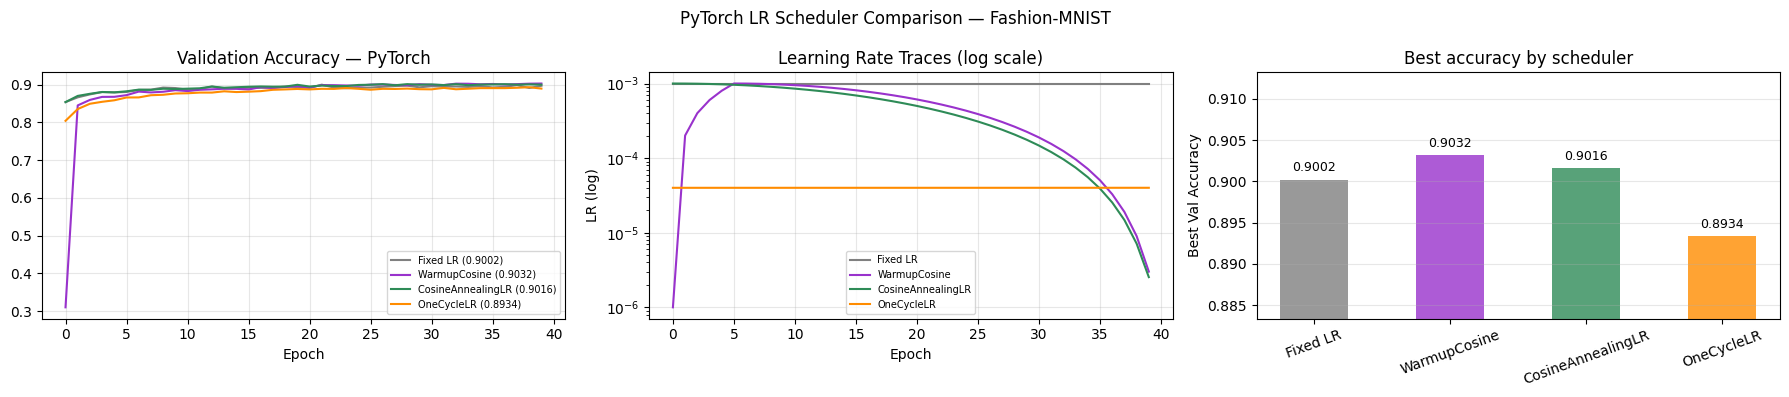

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

results = [
    ('Fixed LR',         hist_fixed,       acc_fixed,        'grey'),
    ('WarmupCosine',     hist_warmcos,     acc_warmcos,      'darkorchid'),
    ('CosineAnnealingLR',hist_cosine,      acc_cosine,       'seagreen'),
    ('OneCycleLR',       hist_onecycle_pt, acc_onecycle_pt,  'darkorange'),
]

for name, hist, best, color in results:
    axes[0].plot(hist['val_acc'], label=f'{name} ({best:.4f})',
                 color=color, linewidth=1.5)
axes[0].set_title('Validation Accuracy — PyTorch')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

for name, hist, best, color in results:
    axes[1].semilogy(hist['lr'], label=name, color=color, linewidth=1.5)
axes[1].set_title('Learning Rate Traces (log scale)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('LR (log)')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

names  = [r[0] for r in results]
bests  = [r[2] for r in results]
colors = [r[3] for r in results]
bars   = axes[2].bar(names, bests, color=colors, alpha=0.8, width=0.5)
for bar, acc in zip(bars, bests):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{acc:.4f}', ha='center', fontsize=9)
axes[2].set_ylabel('Best Val Accuracy')
axes[2].set_title('Best accuracy by scheduler')
axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylim(min(bests) - 0.01, max(bests) + 0.01)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('PyTorch LR Scheduler Comparison — Fashion-MNIST', fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary

### Scheduler Reference

| Scheduler | Shape | Best for | Key param |
|---|---|---|---|
| Fixed LR | Flat | Baseline only | `lr` |
| Step Decay | Staircase | Simple, interpretable | `drop_every` |
| Exponential | Smooth decrease | General purpose | `decay_rate` |
| Cosine Annealing | Smooth S-curve | Most tasks | `T_max` |
| Warmup + Cosine | Ramp then decay | Deep nets, transformers | `warmup_epochs` |
| OneCycleLR | Up then down | Fast training, super-convergence | `max_lr, pct_start` |

### TensorFlow Patterns
```python
# Via callback
tf.keras.callbacks.LearningRateScheduler(lambda epoch, lr: schedule_fn(epoch))

# Via built-in schedule object
optimizer = tf.keras.optimizers.Adam(
    learning_rate=tf.keras.optimizers.schedules.CosineDecay(...)
)

# Via custom callback
class MyScheduler(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        tf.keras.backend.set_value(self.model.optimizer.learning_rate, new_lr)
```

### PyTorch Patterns
```python
# Built-in
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, ...)

# Custom
class MyScheduler(_LRScheduler):
    def get_lr(self):
        return [compute_lr(self.last_epoch) for _ in self.base_lrs]

# Always call after optimizer.step()
optimizer.step()
scheduler.step()   # per epoch or per step depending on scheduler
```

**Next: Notebook 17** — Custom Dropout & Custom Normalization (MCAlphaDropout, MaxNormDense)
